# Test Algorithm Performance

In [12]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor

from hirank import RankOD, BootstrapRankOD

In [2]:
def ood_train_test_split(X, y, hold_out_label, rng=np.random.default_rng()):
    # Split into normal and ood sets
    ood_mask = y == hold_out_label

    X_inlier = X[~ood_mask]
    y_inlier = y[~ood_mask]
    X_outlier = X[ood_mask]
    y_outlier = y[ood_mask]

    inlier_test_mask = np.zeros(X_inlier.shape[0], dtype="bool")
    inlier_test_mask[rng.choice(np.arange(len(inlier_test_mask)), size=np.sum(ood_mask), replace=False)] = True

    X_train = X_inlier[~inlier_test_mask]
    y_train = y_inlier[~inlier_test_mask]
    X_test = np.vstack([X_outlier, X_inlier[inlier_test_mask]])
    y_test = np.concatenate([y_outlier, y_inlier[inlier_test_mask]])
    y_ood = y_test == hold_out_label

    split = {"x_train":X_train, "x_test":X_test, "y_test":y_test, "y_ood":y_ood, "hold_out_label":hold_out_label}
    return split

## Global Parameters

In [3]:
n_samples = 10000

## Load Data

### MNIST

In [4]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

Loading MNIST dataset...
✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(962), 1: np.int64(1134), 2: np.int64(1021), 3: np.int64(969), 4: np.int64(952), 5: np.int64(890), 6: np.int64(980), 7: np.int64(1066), 8: np.int64(1025), 9: np.int64(1001)}


In [5]:
mnist_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in mnist_splits:
    split["dataset"] = "mnist"
len(mnist_splits)

10

## Unbalanced MNIST
Make class 5 and 8 half the training data, make a split with each smaller set held out.

In [6]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Take a subset for faster computation
is_big_class = (y == 5) + (y == 8)
probs = np.empty(len(X))
probs[is_big_class] = 0.5 / np.sum(is_big_class)
probs[~is_big_class] = 0.5 / np.sum(~is_big_class)

indices = np.random.choice(len(X), n_samples, replace=False, p=probs)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

Loading MNIST dataset...
✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(670), 1: np.int64(751), 2: np.int64(631), 3: np.int64(665), 4: np.int64(684), 5: np.int64(2194), 6: np.int64(624), 7: np.int64(688), 8: np.int64(2432), 9: np.int64(661)}


In [7]:
unbalanced_mnist_splits = [ood_train_test_split(X, y, i) for i in [1, 2, 3, 4, 6, 7, 9]]
for split in unbalanced_mnist_splits:
    split["dataset"] = "unbalanced_mnist"
len(mnist_splits)

10

### Fashion MNSIT

In [8]:
fashion = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X = fashion.data.to_numpy()
y = fashion.target.astype(int).to_numpy()

# Take a subset for faster computation
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(976), 1: np.int64(986), 2: np.int64(1002), 3: np.int64(993), 4: np.int64(1031), 5: np.int64(1011), 6: np.int64(1042), 7: np.int64(977), 8: np.int64(955), 9: np.int64(1027)}


In [9]:
fashion_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in fashion_splits:
    split["dataset"] = "fashion"
len(fashion_splits)

10

### Aggregate all splits

In [10]:
splits = mnist_splits + unbalanced_mnist_splits + fashion_splits
len(splits)

27

## Define Methods

In [13]:
rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    random_state = 42,
)

rank_l2_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

rank_l2_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    random_state = 42,
)

rank_l2_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    random_state = 42,
)

rank_l2_invsqrt_local = RankOD(
    mode = "rank",
    calibration = "local",
    random_state = 42,
)

rank_cos_invsqrt_global = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

rank_cos_linear_local = RankOD(
    mode = "rank",
    calibration = "local",
    kernel = "linear",
    metric = "cosine",
    random_state = 42,
)

rank_cos_linear_global = RankOD(
    mode = "rank",
    calibration = "global",
    kernel = "linear",
    metric = "cosine",
    random_state = 42,
)

sun_global = RankOD(
    mode = "sun",
    calibration = "global",
    random_state = 42,
)

sun_local = RankOD(
    mode = "sun",
    calibration = "local",
    random_state = 42,
)

lof = LocalOutlierFactor(
    novelty=True,
)

iso = IsolationForest(
    random_state = 42,
)

def _make_bootstrap_method(method, sample_rate):
    m_function = lambda n: int(sample_rate * n)
    if isinstance(method, RankOD):
        return BootstrapRankOD(
            n_bootstrap_sample = 5,
            m_function = m_function,
            **method.get_params(),
        )

    bootstrap_method = BootstrapRankOD(
        n_bootstrap_sample = 5,
        m_function = m_function,
    )
    bootstrap_method.detectors = [
        clone(method) for _ in range(bootstrap_method.n_bootstrap_sample)
    ]
    return bootstrap_method

rank_l2_invsqrt_local_bs_75 = _make_bootstrap_method(
    rank_l2_invsqrt_local,
    0.75,
)

rank_l2_invsqrt_global_bs_75 = _make_bootstrap_method(
    rank_l2_invsqrt_global,
    0.75,
)

rank_l2_linear_local_bs_75 = _make_bootstrap_method(
    rank_l2_linear_local,
    0.75,
)

rank_l2_linear_global_bs_75 = _make_bootstrap_method(
    rank_l2_linear_global,
    0.75,
)

rank_cos_invsqrt_global_bs_75 = _make_bootstrap_method(
    rank_cos_invsqrt_global,
    0.75,
)

rank_cos_linear_local_bs_75 = _make_bootstrap_method(
    rank_cos_linear_local,
    0.75,
)

rank_cos_linear_global_bs_75 = _make_bootstrap_method(
    rank_cos_linear_global,
    0.75,
)

sun_global_bs_75 = _make_bootstrap_method(
    sun_global,
    0.75,
)

sun_local_bs_75 = _make_bootstrap_method(
    sun_local,
    0.75,
)

lof_bs_75 = _make_bootstrap_method(
    lof,
    0.75,
)

iso_bs_75 = _make_bootstrap_method(
    iso,
    0.75,
)


methods = [
    rank_l2_invsqrt_local,
    rank_l2_invsqrt_global,
    rank_l2_linear_local,
    rank_l2_linear_global,
    rank_l2_invsqrt_local,
    rank_cos_invsqrt_global,
    rank_cos_linear_local,
    rank_cos_linear_global,
    sun_global,
    sun_local,
    lof,
    iso,
    rank_l2_invsqrt_local_bs_75,
    rank_l2_invsqrt_global_bs_75,
    rank_l2_linear_local_bs_75,
    rank_l2_linear_global_bs_75,
    rank_l2_invsqrt_local_bs_75,
    rank_cos_invsqrt_global_bs_75,
    rank_cos_linear_local_bs_75,
    rank_cos_linear_global_bs_75,
    sun_global_bs_75,
    sun_local_bs_75,
    lof_bs_75,
    iso_bs_75,
]

method_names = [
    'rank_l2_invsqrt_local',
    'rank_l2_invsqrt_global',
    'rank_l2_linear_local',
    'rank_l2_linear_global',
    'rank_l2_invsqrt_local',
    'rank_cos_invsqrt_global',
    'rank_cos_linear_local',
    'rank_cos_linear_global',
    'sun_global',
    'sun_local',
    'lof',
    'iso',
    'rank_l2_invsqrt_local_bs_75',
    'rank_l2_invsqrt_global_bs_75',
    'rank_l2_linear_local_bs_75',
    'rank_l2_linear_global_bs_75',
    'rank_l2_invsqrt_local_bs_75',
    'rank_cos_invsqrt_global_bs_75',
    'rank_cos_linear_local_bs_75',
    'rank_cos_linear_global_bs_75',
    'sun_global_bs_75',
    'sun_local_bs_75',
    'lof_bs_75',
    'iso_bs_75',
]

## Run Tests

In [14]:
print(f"Testing {len(methods)} methods on {len(splits)} train/test splits.")
results = []
for split in splits:
    print(f"Testing dataset {split["dataset"]} with ood class {split["hold_out_label"]}")
    for method, method_name in zip(methods, method_names):
        result = {"dataset":split["dataset"], "method":method_name, "ood class":str(split["hold_out_label"])}
        # Warmup cache
        X = np.random.random((200, 30))
        X_test = np.random.random((200, 30))
        with warnings.catch_warnings() as caught:
            warnings.simplefilter("ignore", category=UserWarning)
            method.fit(X)
            method.score_samples(X_test)

        # Fit
        method.fit(split["x_train"])
        # Predict
        scores = method.score_samples(split["x_test"])
        # Evaluate
        result["auroc"] = roc_auc_score(~split["y_ood"], scores)
        results.append(result)

Testing 24 methods on 27 train/test splits.
Testing dataset mnist with ood class 0
Testing dataset mnist with ood class 1
Testing dataset mnist with ood class 2
Testing dataset mnist with ood class 3
Testing dataset mnist with ood class 4
Testing dataset mnist with ood class 5
Testing dataset mnist with ood class 6
Testing dataset mnist with ood class 7
Testing dataset mnist with ood class 8
Testing dataset mnist with ood class 9
Testing dataset unbalanced_mnist with ood class 1
Testing dataset unbalanced_mnist with ood class 2
Testing dataset unbalanced_mnist with ood class 3
Testing dataset unbalanced_mnist with ood class 4
Testing dataset unbalanced_mnist with ood class 6
Testing dataset unbalanced_mnist with ood class 7
Testing dataset unbalanced_mnist with ood class 9
Testing dataset fashion with ood class 0
Testing dataset fashion with ood class 1
Testing dataset fashion with ood class 2
Testing dataset fashion with ood class 3
Testing dataset fashion with ood class 4
Testing dat

In [15]:
df = pd.DataFrame(results)
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.808808
1,mnist,rank_l2_invsqrt_global,0,0.939562
2,mnist,rank_l2_linear_local,0,0.818509
3,mnist,rank_l2_linear_global,0,0.941662
4,mnist,rank_l2_invsqrt_local,0,0.808808
...,...,...,...,...
643,fashion,rank_cos_linear_global_bs_75,9,0.426945
644,fashion,sun_global_bs_75,9,0.803719
645,fashion,sun_local_bs_75,9,0.315139
646,fashion,lof_bs_75,9,0.752666


In [16]:
dataset_means = df.groupby(["dataset", "method"])[["auroc"]].mean().reset_index()
dataset_means["ood class"] = "Average"
df = pd.concat([df, dataset_means])
df

,dataset,method,ood class,auroc
0,mnist,rank_l2_invsqrt_local,0,0.808808
1,mnist,rank_l2_invsqrt_global,0,0.939562
2,mnist,rank_l2_linear_local,0,0.818509
3,mnist,rank_l2_linear_global,0,0.941662
4,mnist,rank_l2_invsqrt_local,0,0.808808
...,...,...,...,...
61,unbalanced_mnist,rank_l2_linear_local_bs_75,Average,0.826482
62,unbalanced_mnist,sun_global,Average,0.860487
63,unbalanced_mnist,sun_global_bs_75,Average,0.857517
64,unbalanced_mnist,sun_local,Average,0.823791


In [17]:
df.to_feather("comparing_modes_results.feather")

In [18]:
# Fix so all plots share hues
hue_order = df["method"].unique().tolist()
hue_order

['rank_l2_invsqrt_local',
 'rank_l2_invsqrt_global',
 'rank_l2_linear_local',
 'rank_l2_linear_global',
 'rank_cos_invsqrt_global',
 'rank_cos_linear_local',
 'rank_cos_linear_global',
 'sun_global',
 'sun_local',
 'lof',
 'iso',
 'rank_l2_invsqrt_local_bs_75',
 'rank_l2_invsqrt_global_bs_75',
 'rank_l2_linear_local_bs_75',
 'rank_l2_linear_global_bs_75',
 'rank_cos_invsqrt_global_bs_75',
 'rank_cos_linear_local_bs_75',
 'rank_cos_linear_global_bs_75',
 'sun_global_bs_75',
 'sun_local_bs_75',
 'lof_bs_75',
 'iso_bs_75']

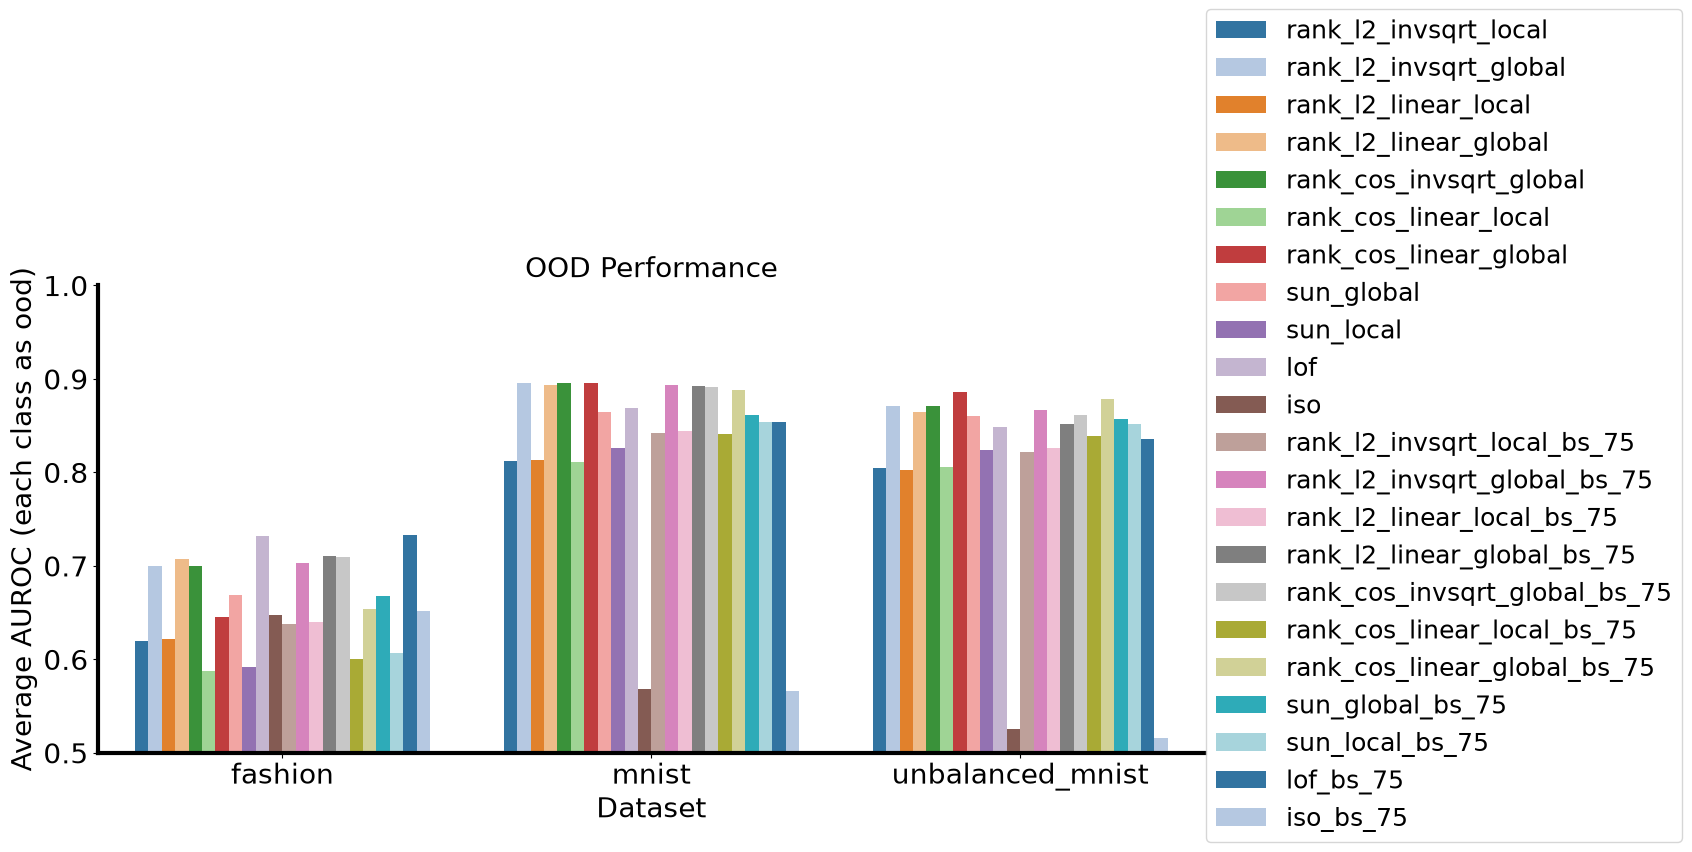

In [26]:
fig, ax = plt.subplots(figsize=(17, 8))

sns.barplot(df[df["ood class"] == "Average"], x="dataset", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance", fontsize=20)
ax.set_xlabel("Dataset", fontsize=20)
ax.set_ylabel("Average AUROC (each class as ood)", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.7), loc="center left", fancybox=True, fontsize=18)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

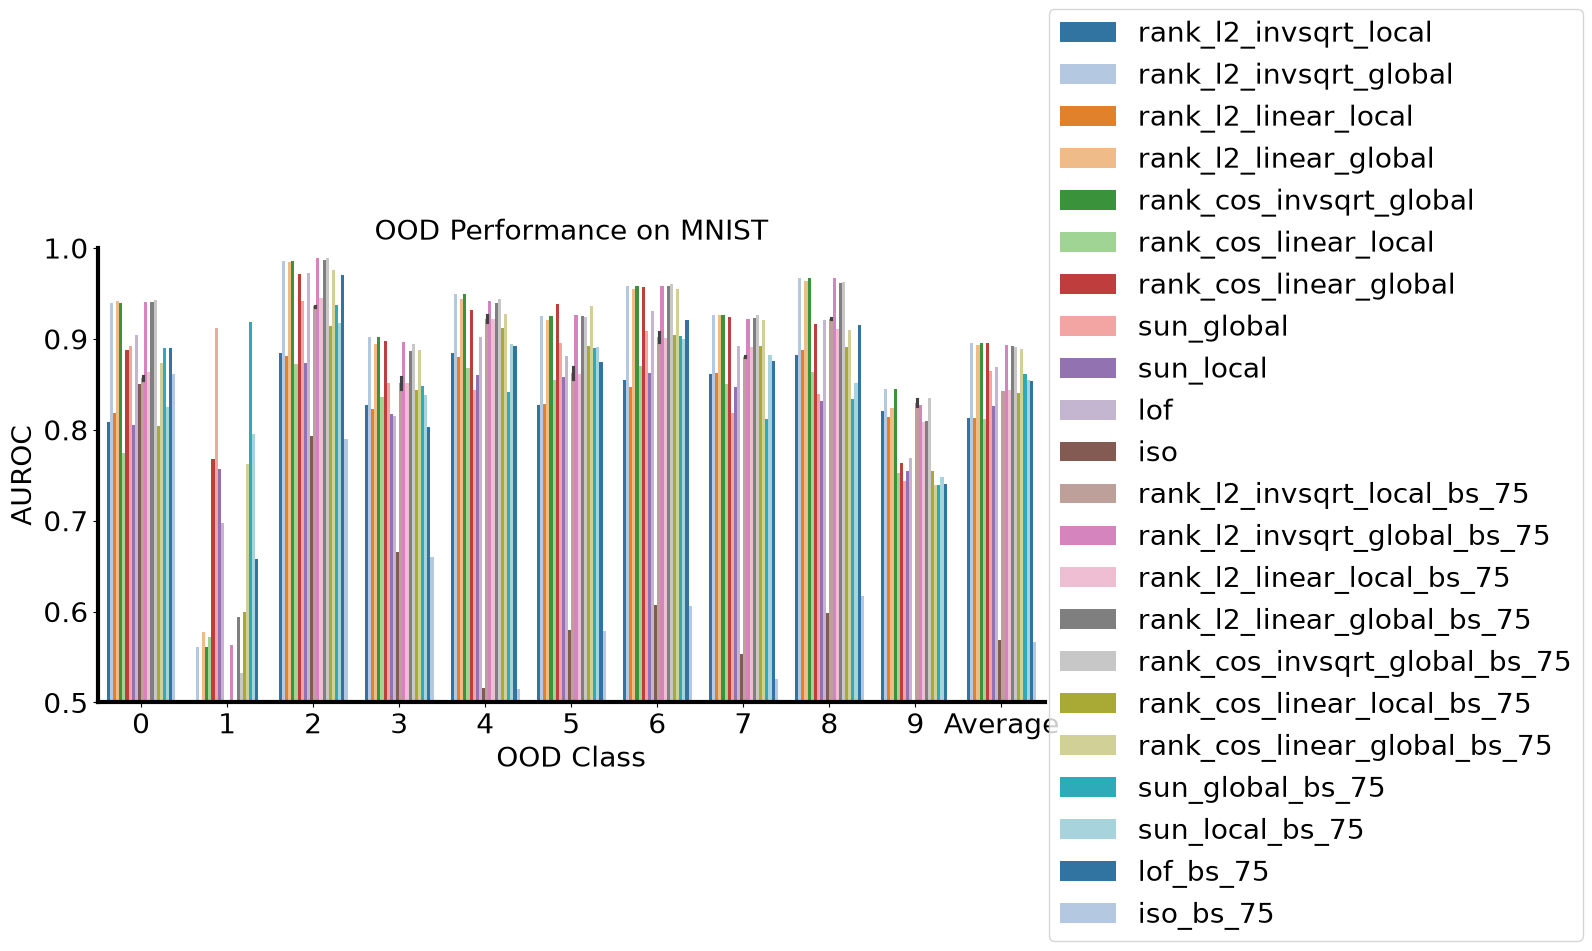

In [22]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "mnist"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.5), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

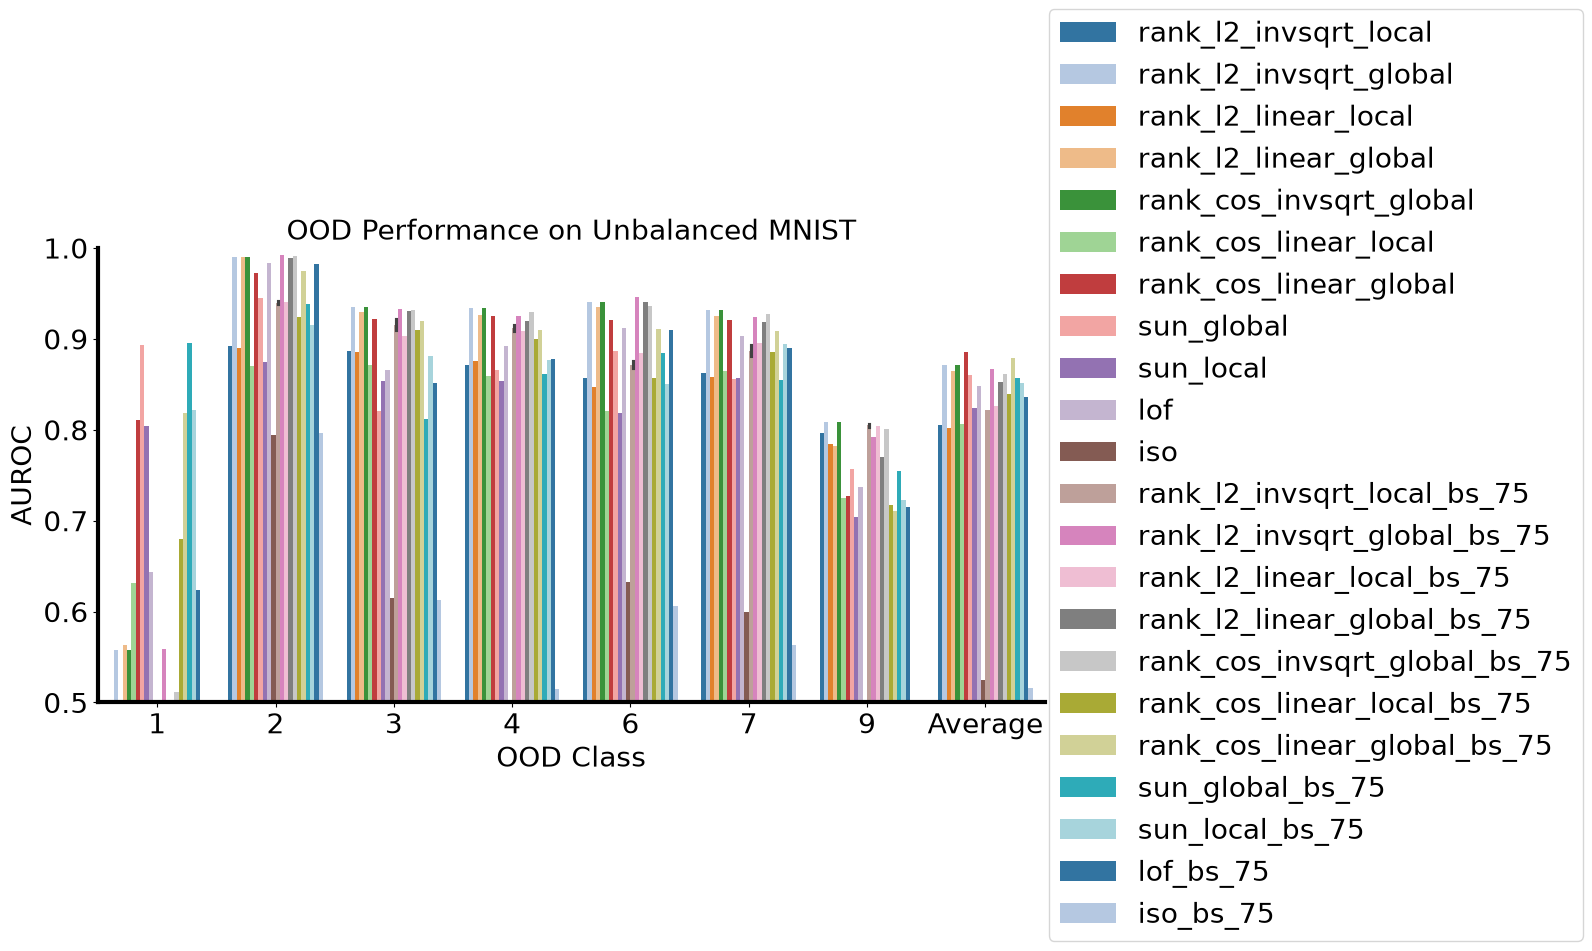

In [23]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "unbalanced_mnist"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on Unbalanced MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.5), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

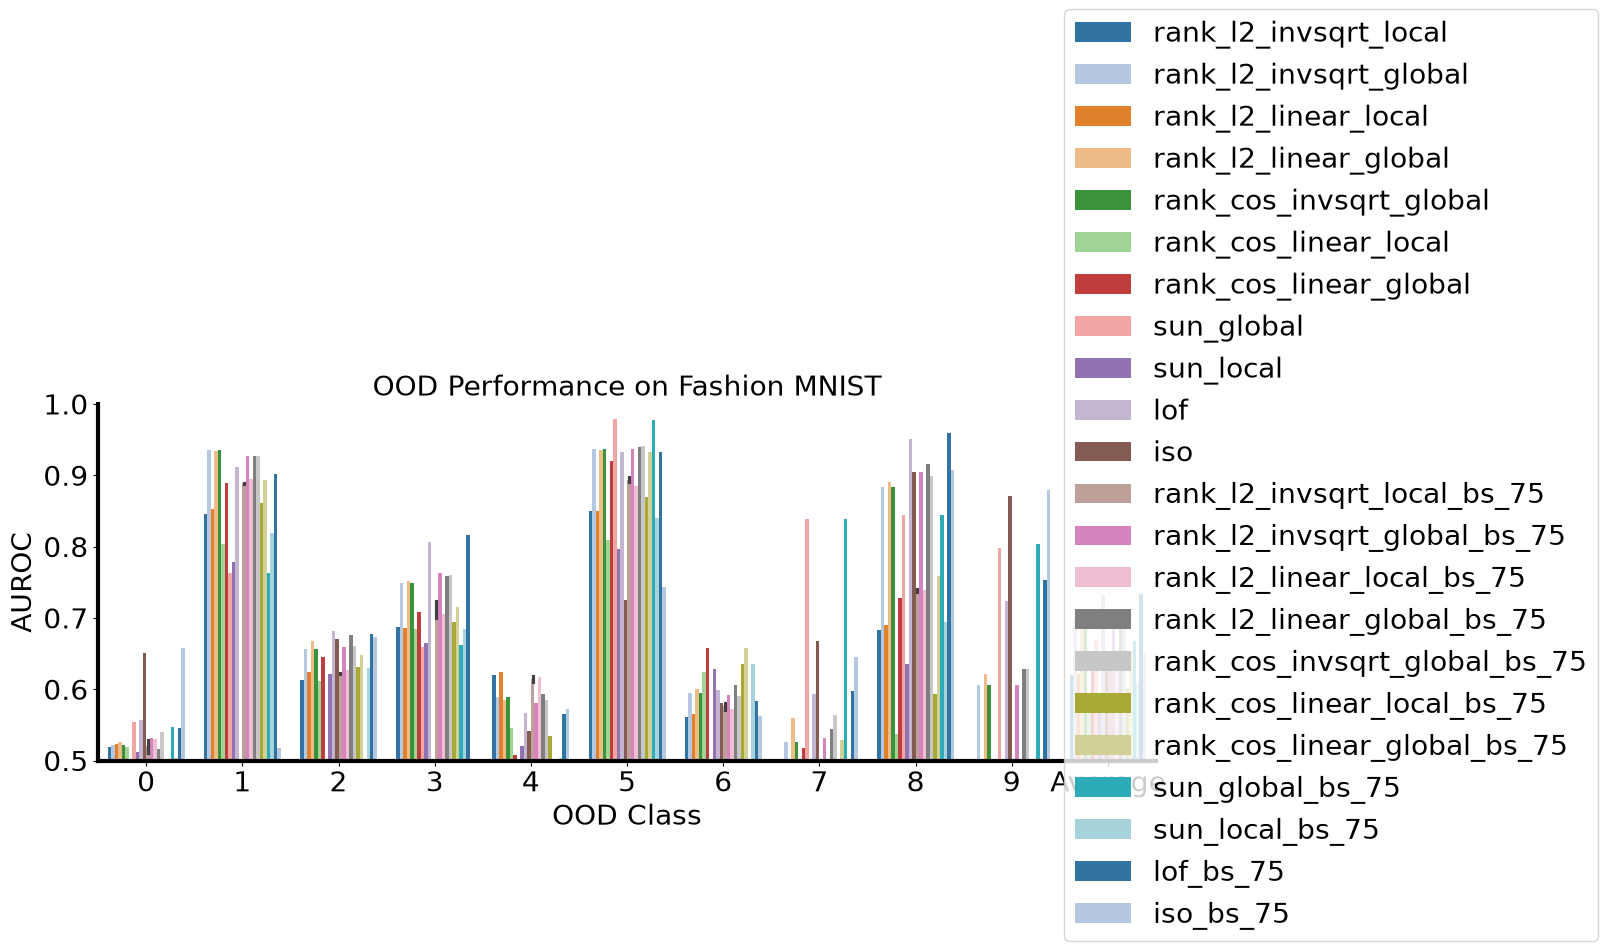

In [24]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "fashion"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="tab20", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on Fashion MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.9, 0.8), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()